In [1]:
# import library & setting
import os
import time
import warnings
from collections import deque
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import DBSCAN  # hanya untuk validasi kelas manual
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    pairwise_distances,
    adjusted_rand_score
)

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

METRIC = 'euclidean'
N_SAMPLE = 10000   # DBSCAN manual dijalankan pada sampel agar muat di RAM Colab
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

OUTPUT_DIR = "/content/drive/MyDrive/ml-sem5/kuis1/outputDBSCAN"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("[INFO] Library berhasil diinstall.")
print(f"[INFO] Folder output: '{OUTPUT_DIR}' | Random state: {RANDOM_STATE} | N_SAMPLE: {N_SAMPLE}")

Mounted at /content/drive
[INFO] Library berhasil diinstall.
[INFO] Folder output: '/content/drive/MyDrive/ml-sem5/kuis1/outputDBSCAN' | Random state: 42 | N_SAMPLE: 10000


In [2]:
# load dataset
df_raw = pd.read_csv('/content/drive/MyDrive/ml-sem5/kuis1/dataset/diabetes_012_health_indicators_BRFSS2015.csv')
print(f"Data awal: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")
df_raw.head()

Data awal: 253680 baris x 22 kolom


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


In [3]:
# cek data awal
print("Tipe data tiap kolom:")
print(df_raw.dtypes.value_counts())

print("\nTotal missing value per kolom (hanya yang > 0):")
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "Tidak ada missing value")

print(f"\nJumlah baris duplikat: {df_raw.duplicated().sum()}")

print("\nSebaran kelas Diabetes_012 (0=tidak, 1=pra-diabetes, 2=diabetes):")
print(df_raw['Diabetes_012'].value_counts().sort_index())

Tipe data tiap kolom:
float64    22
Name: count, dtype: int64

Total missing value per kolom (hanya yang > 0):
Tidak ada missing value

Jumlah baris duplikat: 23899

Sebaran kelas Diabetes_012 (0=tidak, 1=pra-diabetes, 2=diabetes):
Diabetes_012
0.0    213703
1.0      4631
2.0     35346
Name: count, dtype: int64


In [4]:
# preprocessing + sampling
df = df_raw.copy()
n_awal = len(df)

df = df[df['Diabetes_012'] != 1]   # buang kelas 1 (pra-diabetes)
print(f"Setelah buang kelas 1      : {len(df)} baris (terbuang {n_awal - len(df)})")

df = df.drop(columns=['Income'])
print(f"Setelah buang kolom Income : {df.shape[1]} kolom")

n_sebelum_dup = len(df)
df = df.drop_duplicates()
print(f"Setelah hapus duplikat     : {len(df)} baris (terbuang {n_sebelum_dup - len(df)})")

df = df.reset_index(drop=True)

y_label = df['Diabetes_012'].copy()   # label hanya untuk pembanding, tidak dipakai klastering
df_features = df.drop(columns=['Diabetes_012']).astype(float)
print(f"Jumlah fitur untuk klastering: {df_features.shape[1]}")
print(f"Daftar fitur: {list(df_features.columns)}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features.values)
print(f"Bentuk data siap klaster: {X_scaled.shape}")
print(f"Cek mean 0 dan std 1: {X_scaled.mean():.4f} / {X_scaled.std():.4f}")

# Sampling untuk DBSCAN
rng = np.random.RandomState(RANDOM_STATE)
idx_sample = np.sort(rng.choice(len(X_scaled), size=N_SAMPLE, replace=False))
X_sample = X_scaled[idx_sample]
y_sample = y_label.iloc[idx_sample].reset_index(drop=True)
df_sample = df_features.iloc[idx_sample].reset_index(drop=True)
print(f"[SAMPEL] Data klastering: {X_sample.shape[0]} baris x {X_sample.shape[1]} kolom")
print(f"[SAMPEL] Sebaran label (pembanding): {y_sample.value_counts().sort_index().to_dict()}")
df_sample.head()

Setelah buang kelas 1      : 249049 baris (terbuang 4631)
Setelah buang kolom Income : 21 kolom
Setelah hapus duplikat     : 208858 baris (terbuang 40191)
Jumlah fitur untuk klastering: 20
Daftar fitur: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education']
Bentuk data siap klaster: (208858, 20)
Cek mean 0 dan std 1: -0.0000 / 1.0000
[SAMPEL] Data klastering: 10000 baris x 20 kolom
[SAMPEL] Sebaran label (pembanding): {0.0: 8316, 2.0: 1684}


,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education
0,0.0,0.0,1.0,26.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,3.0,0.0,15.0,0.0,0.0,7.0,5.0
1,1.0,1.0,1.0,27.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,2.0,4.0,2.0,0.0,1.0,7.0,6.0
2,1.0,1.0,1.0,30.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,1.0,9.0,6.0
3,1.0,1.0,1.0,32.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,0.0,0.0,0.0,1.0,7.0,4.0
4,0.0,0.0,0.0,24.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0,10.0,0.0,0.0,0.0,6.0,3.0


[PARAM] MinPts = 40
[K-DIST] Saran eps dari siku kurva: 4.6127
[K-DIST] Persentil ke-50: 2.7690
[K-DIST] Persentil ke-75: 3.6467
[K-DIST] Persentil ke-90: 4.4344
[K-DIST] Persentil ke-95: 4.9454
[K-DIST] Persentil ke-99: 6.0649
[SIMPAN] Grafik k-distance disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputDBSCAN/kdistance_euclidean.png'


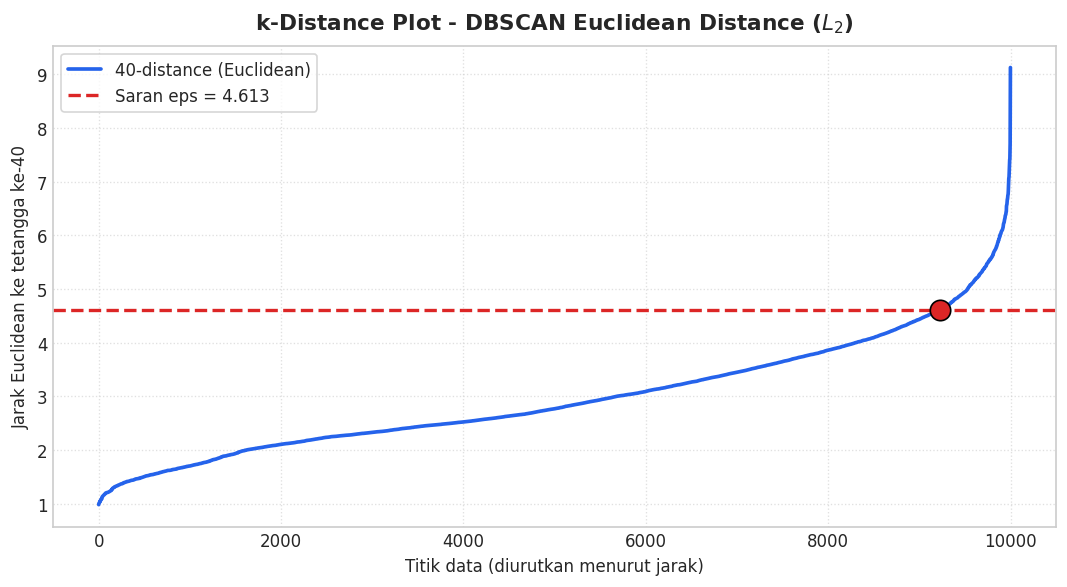

In [5]:
# k-distance plot untuk menentukan eps (pengganti Elbow Method)
MIN_PTS = 2 * X_sample.shape[1]   # heuristik: 2 x jumlah fitur
print(f"[PARAM] MinPts = {MIN_PTS}")

nbrs = NearestNeighbors(n_neighbors=MIN_PTS, metric=METRIC, algorithm='brute', n_jobs=-1).fit(X_sample)
distances, _ = nbrs.kneighbors(X_sample)
k_dist = np.sort(distances[:, -1])

def find_knee_point(y_vals):
    x = np.arange(len(y_vals), dtype=float)
    xn = (x - x.min()) / (x.max() - x.min())
    yn = (y_vals - y_vals.min()) / (y_vals.max() - y_vals.min())
    p1 = np.array([xn[0], yn[0]])
    line_unit = np.array([xn[-1], yn[-1]]) - p1
    line_unit = line_unit / np.linalg.norm(line_unit)
    pts = np.column_stack([xn, yn]) - p1
    proj = np.outer(pts @ line_unit, line_unit)
    return int(np.argmax(np.linalg.norm(pts - proj, axis=1)))

knee_idx = find_knee_point(k_dist)
eps_suggest = float(k_dist[knee_idx])
print(f"[K-DIST] Saran eps dari siku kurva: {eps_suggest:.4f}")
for q in [50, 75, 90, 95, 99]:
    print(f"[K-DIST] Persentil ke-{q}: {np.percentile(k_dist, q):.4f}")

plt.figure(figsize=(9, 5))
plt.plot(k_dist, linewidth=2.2, color='#2563EB', label=f'{MIN_PTS}-distance (Euclidean)')
plt.axhline(eps_suggest, color='#DC2626', linestyle='--', linewidth=2, label=f'Saran eps = {eps_suggest:.3f}')
plt.scatter([knee_idx], [eps_suggest], color='#DC2626', s=150, zorder=5, edgecolor='black')
plt.title('k-Distance Plot - DBSCAN Euclidean Distance ($L_2$)', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Titik data (diurutkan menurut jarak)')
plt.ylabel(f'Jarak Euclidean ke tetangga ke-{MIN_PTS}')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()

kdist_path = os.path.join(OUTPUT_DIR, "kdistance_euclidean.png")
plt.savefig(kdist_path, dpi=300)
print(f"[SIMPAN] Grafik k-distance disimpan ke: '{kdist_path}'")
plt.show()

In [6]:
# class DBSCAN Euclidean (implementasi manual)
class DBSCANEuclidean:
    def __init__(self, eps=0.5, min_pts=5, chunk_size=1000):
        self.eps = eps
        self.min_pts = min_pts
        self.chunk_size = chunk_size
        self.labels_ = None
        self.core_sample_mask_ = None
        self.n_clusters_ = 0
        self.n_noise_ = 0
        self.execution_time_ = 0.0

    def _neighborhoods(self, X):
        # N_eps(p) = { q | ||p - q||_2 <= eps }, termasuk p sendiri; dihitung per potongan agar hemat RAM
        out = []
        for s in range(0, len(X), self.chunk_size):
            d = pairwise_distances(X[s:s + self.chunk_size], X, metric='euclidean', n_jobs=-1)
            out.extend(np.where(row <= self.eps)[0].astype(np.int32) for row in d)
        return out

    def fit(self, X):
        start = time.perf_counter()
        n = X.shape[0]
        neighborhoods = self._neighborhoods(X)
        is_core = np.array([len(nb) >= self.min_pts for nb in neighborhoods])

        labels = np.full(n, -1, dtype=int)   # -1 = noise
        visited = np.zeros(n, dtype=bool)
        cluster_id = 0

        for p in range(n):
            if visited[p] or not is_core[p]:
                continue
            visited[p] = True
            labels[p] = cluster_id
            seeds = deque([p])
            while seeds:
                q = seeds.popleft()
                nb = neighborhoods[q]
                labels[nb[labels[nb] == -1]] = cluster_id          # border/core masuk klaster ini
                new_core = nb[(~visited[nb]) & is_core[nb]]        # core baru ikut diekspansi
                visited[new_core] = True
                seeds.extend(new_core.tolist())
            cluster_id += 1

        self.labels_ = labels
        self.core_sample_mask_ = is_core
        self.n_clusters_ = cluster_id
        self.n_noise_ = int(np.sum(labels == -1))
        self.execution_time_ = float(time.perf_counter() - start)
        return self

print("[INFO] Kelas DBSCANEuclidean berhasil diinisialisasi.")

[INFO] Kelas DBSCANEuclidean berhasil diinisialisasi.


In [7]:
# uji validasi terhadap DBSCAN sklearn
EPS_TEST = float(np.percentile(k_dist, 70))

mine = DBSCANEuclidean(eps=EPS_TEST, min_pts=MIN_PTS).fit(X_sample)
ref = DBSCAN(eps=EPS_TEST, min_samples=MIN_PTS, metric='euclidean').fit(X_sample)

ref_core = np.zeros(len(X_sample), dtype=bool)
ref_core[ref.core_sample_indices_] = True

print(f"[VALIDASI] eps = {EPS_TEST:.4f} | MinPts = {MIN_PTS}")
print(f"[VALIDASI] Manual : {mine.n_clusters_} klaster, {mine.n_noise_} noise, {mine.execution_time_:.2f} detik")
print(f"[VALIDASI] sklearn: {len(set(ref.labels_)) - (1 if -1 in ref.labels_ else 0)} klaster, {int(np.sum(ref.labels_ == -1))} noise")
print(f"[VALIDASI] Core point identik : {np.array_equal(mine.core_sample_mask_, ref_core)}")
print(f"[VALIDASI] Noise identik      : {np.array_equal(mine.labels_ == -1, ref.labels_ == -1)}")
print(f"[VALIDASI] Adjusted Rand Index: {adjusted_rand_score(ref.labels_, mine.labels_):.4f}")

[VALIDASI] eps = 3.4479 | MinPts = 40
[VALIDASI] Manual : 5 klaster, 1498 noise, 3.41 detik
[VALIDASI] sklearn: 5 klaster, 1498 noise
[VALIDASI] Core point identik : True
[VALIDASI] Noise identik      : True
[VALIDASI] Adjusted Rand Index: 1.0000


In [8]:
# uji beberapa nilai eps
eps_candidates = sorted(set(round(float(np.percentile(k_dist, q)), 4) for q in [50, 60, 70, 80, 90, 95]) | {round(eps_suggest, 4)})
rows = []

for eps in eps_candidates:
    m = DBSCANEuclidean(eps=eps, min_pts=MIN_PTS).fit(X_sample)
    lab = m.labels_
    mk = lab != -1
    largest = np.bincount(lab[mk]).max() / len(lab) * 100 if m.n_clusters_ > 0 else 0.0

    if m.n_clusters_ >= 2:
        sil = silhouette_score(X_sample[mk], lab[mk], metric='euclidean')
    else:
        sil = np.nan

    rows.append({
        'eps': eps,
        'Jumlah Klaster': m.n_clusters_,
        'Noise (n)': m.n_noise_,
        'Noise (%)': round(m.n_noise_ / len(lab) * 100, 2),
        'Klaster Terbesar (%)': round(largest, 2),
        'Core Point (n)': int(m.core_sample_mask_.sum()),
        'Silhouette (non-noise)': round(sil, 4) if not np.isnan(sil) else np.nan,
        'Waktu (s)': round(m.execution_time_, 2)
    })
    print(f"[SWEEP] eps={eps} -> {m.n_clusters_} klaster, noise {m.n_noise_ / len(lab) * 100:.2f}%")

sweep_df = pd.DataFrame(rows)
print("\n" + "=" * 100)
print("TABEL UJI EPS - DBSCAN EUCLIDEAN")
print("=" * 100)
print(sweep_df.to_string(index=False))

sweep_path = os.path.join(OUTPUT_DIR, "eps_sweep_euclidean.csv")
sweep_df.to_csv(sweep_path, index=False)
print(f"[SIMPAN] Tabel uji eps disimpan ke: '{sweep_path}'")

[SWEEP] eps=2.769 -> 6 klaster, noise 31.18%
[SWEEP] eps=3.0908 -> 6 klaster, noise 23.49%
[SWEEP] eps=3.4479 -> 5 klaster, noise 14.98%
[SWEEP] eps=3.8596 -> 5 klaster, noise 8.01%
[SWEEP] eps=4.4344 -> 3 klaster, noise 3.08%
[SWEEP] eps=4.6127 -> 3 klaster, noise 2.17%
[SWEEP] eps=4.9454 -> 1 klaster, noise 0.98%

TABEL UJI EPS - DBSCAN EUCLIDEAN
   eps  Jumlah Klaster  Noise (n)  Noise (%)  Klaster Terbesar (%)  Core Point (n)  Silhouette (non-noise)  Waktu (s)
2.7690               6       3118      31.18                 57.56            5000                  0.1664       2.15
3.0908               6       2349      23.49                 61.51            5999                  0.1702       2.61
3.4479               5       1498      14.98                 74.63            7000                  0.2060       2.26
3.8596               5        801       8.01                 78.32            8000                  0.2014       3.48
4.4344               3        308       3.08               

In [14]:
# model final, evaluasi, profil klaster, simpan hasil
EPS_MANUAL = None

ok = sweep_df[(sweep_df['Jumlah Klaster'] >= 2) & (sweep_df['Noise (%)'] <= 30)]
if EPS_MANUAL is not None:
    EPS_FINAL = float(EPS_MANUAL)
elif len(ok) > 0:
    EPS_FINAL = float(ok.sort_values('Silhouette (non-noise)', ascending=False).iloc[0]['eps'])   # klaster >= 2, noise <= 30%, silhouette tertinggi
else:
    EPS_FINAL = float(eps_suggest)
print(f"[FINAL] eps = {EPS_FINAL} | MinPts = {MIN_PTS}")

model_dbscan = DBSCANEuclidean(eps=EPS_FINAL, min_pts=MIN_PTS).fit(X_sample)
labels = model_dbscan.labels_
mask = labels != -1
n_total = len(labels)

# Metrik dihitung pada titik non-noise (noise bukan klaster)
if model_dbscan.n_clusters_ >= 2:
    sil_score = float(silhouette_score(X_sample[mask], labels[mask], metric='euclidean'))
    db_score = float(davies_bouldin_score(X_sample[mask], labels[mask]))
    ch_score = float(calinski_harabasz_score(X_sample[mask], labels[mask]))
else:
    sil_score = db_score = ch_score = np.nan

sizes = np.bincount(labels[mask]) if model_dbscan.n_clusters_ > 0 else np.array([0])

eval_df = pd.DataFrame([{
    'Distance Metric': 'Euclidean Distance (L2)',
    'eps': EPS_FINAL,
    'MinPts': MIN_PTS,
    'Jumlah Data Dipakai': n_total,
    'Jumlah Fitur': X_sample.shape[1],
    'Jumlah Klaster': model_dbscan.n_clusters_,
    'Klaster >=1% data': int(np.sum(sizes >= 0.01 * n_total)),
    'Noise (n)': model_dbscan.n_noise_,
    'Noise (%)': round(model_dbscan.n_noise_ / n_total * 100, 2),
    'Core Point (n)': int(model_dbscan.core_sample_mask_.sum()),
    'Silhouette Score (non-noise) (↑)': round(sil_score, 4),
    'Davies–Bouldin Index (non-noise) (↓)': round(db_score, 4),
    'Calinski–Harabasz Index (non-noise) (↑)': round(ch_score, 2),
    'Execution Time (s) (↓)': round(model_dbscan.execution_time_, 5)
}])

print("\n" + "=" * 80)
print("TABEL EVALUASI DBSCAN EUCLIDEAN")
print("=" * 80)
print(eval_df.T.to_string(header=False))
print("=" * 80)

df_result = df_sample.copy()
df_result['Cluster_DBSCAN'] = labels
df_result['Diabetes_012'] = y_sample.values

profil = df_result.groupby('Cluster_DBSCAN').mean().round(3)
profil.insert(0, 'Jumlah Data', df_result.groupby('Cluster_DBSCAN').size())
profil['% Diabetes'] = df_result.groupby('Cluster_DBSCAN')['Diabetes_012'].apply(lambda s: (s == 2).mean() * 100).round(2)

excel_path = os.path.join(OUTPUT_DIR, "evaluasi_dbscan_euclidean.xlsx")
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    eval_df.to_excel(writer, sheet_name='Ringkasan_Evaluasi', index=False)
    profil.to_excel(writer, sheet_name='Profil_Klaster')
print(f"[SIMPAN] Evaluasi & profil klaster disimpan ke: '{excel_path}'")

csv_path = os.path.join(OUTPUT_DIR, "data_terklaster_dbscan_euclidean.csv")
df_result.to_csv(csv_path, index=False)
print(f"[SIMPAN] Data terklaster disimpan ke: '{csv_path}'")


[FINAL] eps = 4.6127 | MinPts = 40

TABEL EVALUASI DBSCAN EUCLIDEAN
Distance Metric                          Euclidean Distance (L2)
eps                                                       4.6127
MinPts                                                        40
Jumlah Data Dipakai                                        10000
Jumlah Fitur                                                  20
Jumlah Klaster                                                 3
Klaster >=1% data                                              3
Noise (n)                                                    217
Noise (%)                                                   2.17
Core Point (n)                                              9230
Silhouette Score (non-noise) (↑)                          0.2296
Davies–Bouldin Index (non-noise) (↓)                      1.5831
Calinski–Harabasz Index (non-noise) (↑)                   546.85
Execution Time (s) (↓)                                   3.05175
[SIMPAN] Evaluasi & pr

In [15]:
# profil tiap klaster (label -1 = noise)
profil

,Jumlah Data,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Diabetes_012,% Diabetes
Cluster_DBSCAN,,,,,,,,,,,,,,,,,,,,,
-1,217,0.590,0.525,0.668,33.590,0.650,0.401,0.276,0.461,0.424,...,0.553,3.512,13.604,13.779,0.562,0.465,7.631,4.249,0.424,21.20
0,9032,0.460,0.447,1.000,28.709,0.463,0.000,0.095,0.735,0.597,...,0.090,2.596,3.575,4.534,0.173,0.436,7.942,4.980,0.333,16.65
1,371,0.167,0.170,0.000,26.714,0.410,0.000,0.011,0.801,0.617,...,0.111,2.078,2.081,1.596,0.046,0.507,6.569,5.078,0.022,1.08
2,380,0.755,0.642,1.000,28.934,0.608,1.000,0.450,0.632,0.600,...,0.074,3.387,4.618,9.250,0.453,0.450,10.168,4.674,0.684,34.21


[SIMPAN] Grafik pemetaan klaster disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputDBSCAN/cluster_dbscan_euclidean.png'


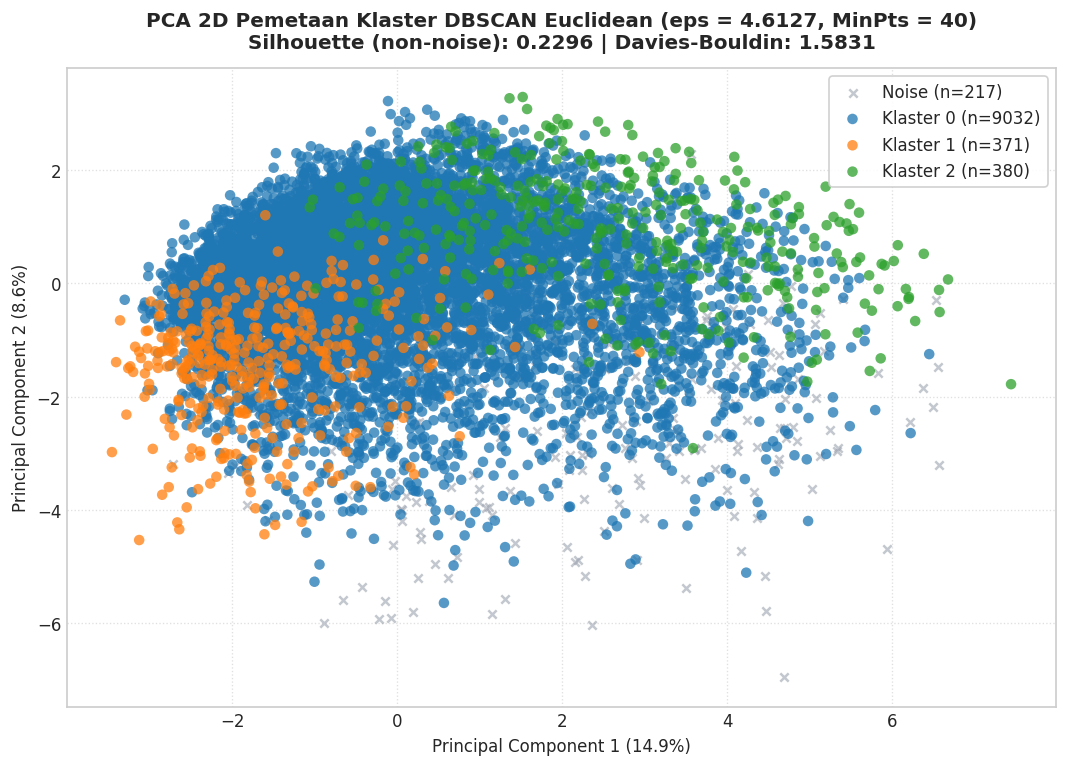

In [16]:
# visualisasi PCA 2D pemetaan klaster
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_sample)

plt.figure(figsize=(9, 6.5))
n_cl = model_dbscan.n_clusters_
palette = sns.color_palette("tab10", max(n_cl, 1))

m_noise = labels == -1
plt.scatter(X_pca[m_noise, 0], X_pca[m_noise, 1], c='#9CA3AF', marker='x', s=25, alpha=0.6,
            label=f'Noise (n={m_noise.sum()})')
for k in range(n_cl):
    mk = labels == k
    plt.scatter(X_pca[mk, 0], X_pca[mk, 1], color=palette[k], s=40, alpha=0.75, edgecolors='none',
                label=f'Klaster {k} (n={mk.sum()})')

plt.title(f'PCA 2D Pemetaan Klaster DBSCAN Euclidean (eps = {EPS_FINAL}, MinPts = {MIN_PTS})\n'
          f'Silhouette (non-noise): {sil_score:.4f} | Davies-Bouldin: {db_score:.4f}',
          fontsize=12, fontweight='bold', pad=12)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0] * 100:.1f}%)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1] * 100:.1f}%)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white', framealpha=0.9, loc='best')
plt.tight_layout()

cluster_path = os.path.join(OUTPUT_DIR, "cluster_dbscan_euclidean.png")
plt.savefig(cluster_path, dpi=300)
print(f"[SIMPAN] Grafik pemetaan klaster disimpan ke: '{cluster_path}'")
plt.show()


In [17]:
# fitur paling berpengaruh di PC1 & PC2
loadings = pd.DataFrame(pca.components_.T, index=df_features.columns, columns=['PC1', 'PC2'])
print("Fitur paling berpengaruh di PC1:")
print(loadings['PC1'].abs().sort_values(ascending=False).head(6).round(3))
print("\nFitur paling berpengaruh di PC2:")
print(loadings['PC2'].abs().sort_values(ascending=False).head(6).round(3))

Fitur paling berpengaruh di PC1:
GenHlth                 0.426
DiffWalk                0.382
PhysHlth                0.361
HighBP                  0.298
HeartDiseaseorAttack    0.260
Age                     0.244
Name: PC1, dtype: float64

Fitur paling berpengaruh di PC2:
Age              0.443
NoDocbcCost      0.406
MentHlth         0.355
AnyHealthcare    0.349
HighBP           0.287
HighChol         0.264
Name: PC2, dtype: float64


In [18]:
# klaster vs label diabetes (pembanding)
label_vs = pd.crosstab(df_result['Cluster_DBSCAN'], df_result['Diabetes_012'])
label_vs.columns = ['Tidak Diabetes (0)' if c == 0 else 'Diabetes (2)' for c in label_vs.columns]
label_vs['Total'] = label_vs.sum(axis=1)
if 'Diabetes (2)' in label_vs.columns:
    label_vs['Diabetes (%)'] = (label_vs['Diabetes (2)'] / label_vs['Total'] * 100).round(2)
print(f"Proporsi diabetes seluruh sampel = {(y_sample == 2).mean() * 100:.2f}%")
print(label_vs.to_string())

if model_dbscan.n_clusters_ >= 2:
    ari = adjusted_rand_score(y_sample.values[mask], labels[mask])
    print(f"\nARI klaster vs label (non-noise): {ari:.4f}")
diab_noise = int(((labels == -1) & (y_sample.values == 2)).sum())
print(f"Diabetes di noise: {diab_noise} dari {int((y_sample == 2).sum())}")

Proporsi diabetes seluruh sampel = 16.84%
                Tidak Diabetes (0)  Diabetes (2)  Total  Diabetes (%)
Cluster_DBSCAN                                                       
-1                             171            46    217         21.20
 0                            7528          1504   9032         16.65
 1                             367             4    371          1.08
 2                             250           130    380         34.21

ARI klaster vs label (non-noise): 0.0067
Diabetes di noise: 46 dari 1684


In [19]:
# cell 14 : bukti pendukung - jarak satu perbedaan pada fitur biner
# Setelah standardisasi, satu perbedaan pada fitur biner bernilai 1/sigma.
# Kalau nilainya > eps, dua titik yang beda di fitur itu tidak mungkin bertetangga.
gap_rows = []
for col, sigma in zip(df_features.columns, scaler.scale_):
    if df_features[col].nunique() == 2:
        gap_rows.append({
            'Fitur': col,
            'Proporsi nilai 1': round(df_features[col].mean(), 3),
            'Sigma': round(sigma, 4),
            'Jarak 1 perbedaan': round(1 / sigma, 3),
            f'Melebihi eps ({EPS_FINAL})': (1 / sigma) > EPS_FINAL
        })

gap_df = pd.DataFrame(gap_rows).sort_values('Jarak 1 perbedaan', ascending=False)
print("Jarak Euclidean untuk satu perbedaan pada fitur biner:")
print(gap_df.to_string(index=False))

bukti_path = os.path.join(OUTPUT_DIR, "bukti_jarak_fitur_biner_euclidean.xlsx")
gap_df.to_excel(bukti_path, index=False)
print(f"[SIMPAN] Disimpan ke: '{bukti_path}'")

Jarak Euclidean untuk satu perbedaan pada fitur biner:
               Fitur  Proporsi nilai 1  Sigma  Jarak 1 perbedaan  Melebihi eps (4.6127)
           CholCheck             0.957 0.2037              4.910                   True
              Stroke             0.048 0.2135              4.684                   True
       AnyHealthcare             0.942 0.2333              4.287                  False
   HvyAlcoholConsump             0.065 0.2461              4.063                  False
         NoDocbcCost             0.099 0.2985              3.350                  False
HeartDiseaseorAttack             0.109 0.3115              3.211                  False
            DiffWalk             0.197 0.3978              2.514                  False
             Veggies             0.784 0.4113              2.431                  False
        PhysActivity             0.719 0.4497              2.224                  False
              Fruits             0.600 0.4899              2.041 